# **Lab: Process Multimodal Data with LLMs**

# **实验：使用 LLM 处理多模态数据**


Estimated time needed: **45** minutes

所需估计时间：**45** 分钟


## **Scenario**

## **场景**


### **Background**

### **背景**

You transformed unstructured restaurant descriptions into a structured JSON knowledge base using LLMs. 你使用 LLM 将非结构化的餐厅描述转化为了结构化的 JSON 知识库。

This allowed the app to reason over textual attributes such as cuisine type, pricing, and signature dishes in a consistent, machine-readable format. 这使得应用程序能够以一致且可机器读取的方式对菜系类型、价格和招牌菜等文本属性进行推理。

However, the app’s data is not limited to text. 然而，应用程序的数据并不局限于文本。

It also includes food recipes and user visit histories that reference images, capturing visual information that text alone cannot fully describe, such as presentation style, ingredients, and portion details. 它还包含引用图像的食谱和用户访问历史，这些内容捕捉了仅靠文本无法完整描述的视觉信息，例如呈现风格、食材和分量细节。

To unlock this information and integrate it with the original databases, you will use multimodal GenAI capabilities to convert images into descriptive text and enrich the structured knowledge you have. 为了挖掘这些信息并将其与原始数据库集成，你将使用多模态生成式人工智能能力，将图像转换为描述性文本，并丰富你已有的结构化知识。

### **The challenge**

### **挑战**

Images are inherently unstructured and cannot be directly stored or queried in a text-based knowledge system. 图像本质上是非结构化的，不能直接存储或在基于文本的知识系统中进行查询。

To make them usable, you must first generate high-quality textual descriptions that summarize the visual content of each image. 为了使它们可用，你必须首先生成高质量的文本描述，以概括每张图像的视觉内容。

Your challenge in this lab is to: 你在这个实验中的挑战是：

* Apply image captioning to generate descriptive text for food images. 应用图像字幕生成技术为食物图像生成描述性文本。
* Align and merge image captions with the corresponding recipe and restaurant JSON records. 将图像字幕与相应的食谱和餐厅 JSON 记录对齐并合并。
* Extend the existing structured knowledge base with multimodal context while preserving a consistent schema. 在保持一致模式的前提下，用多模态上下文扩展现有的结构化知识库。

By the end of this lab, you will have enriched your restaurant knowledge base with visual insights. 到实验结束时，你将用视觉见解丰富餐厅知识库。

You will bridge text and images into a unified, machine-accessible representation, setting the stage for more intelligent multimodal reasoning in later assignments. 你将把文本和图像桥接为一个统一的、可被机器访问的表示形式，为后续作业中更智能的多模态推理打下基础。


## **Objectives**

## **目标**

In this lab, you will write a Python program that will: 在这个实验中，你将编写一个 Python 程序来：

* Load food recipe and user visit data containing image references. 加载包含图像引用的食谱和用户访问数据。
* Use a multimodal foundation model to generate textual captions for food images. 使用多模态基础模型为食物图像生成文本标题。
* Integrate the generated image captions into the existing structured JSON data. 将生成的图像标题整合到现有的结构化 JSON 数据中。
* Produce an enriched multimodal JSON knowledge file for downstream applications. 为下游应用生成一个增强后的多模态 JSON 知识文件。


## **Important: About the lab environment**

## **重要：关于实验环境**


Please be aware that sessions for this lab environment are not persisted. Every time you connect to this lab, a new environment is created for you. Any data you may have saved in the earlier session would get lost. Plan to complete these labs in a single session, to avoid losing your data.

请注意，这个实验环境的会话不会持久保存。每次连接到这个实验时，都会为你创建一个新的环境。你在前一个会话中保存的任何数据都可能会丢失。请计划在单次会话中完成这些实验，以避免丢失数据。


## **Screenshot requirement for this lab**

## **本实验的截图要求**


You will be prompted to take a screenshot and save it on your own device. You will need this screenshot either to answer graded quiz questions or to upload as your submission for the Final Project at the end of this course. You can use various free screen-grabbing tools or your operating system's shortcut keys to do this (for example, `Alt+PrintScreen` on Windows and `Command+shift+4` on Mac).

你将被提示拍摄截图并保存到你自己的设备上。你需要这个截图来回答分级测验问题，或者在课程结尾作为最终项目的提交文件上传。你可以使用各种免费截图工具或操作系统的快捷键来完成这一步（例如 Windows 上的 `Alt+PrintScreen`，Mac 上的 `Command+shift+4`）。

**Note**: The screenshot can be saved with either the **.jpg** or **.png** extension.

**注意**：截图可以保存为 **.jpg** 或 **.png** 格式。


----


## **Set up the lab environment**

## **设置实验环境**


For this lab, you will still be using the following libraries: 对于这个实验，你仍然会使用以下库：

* [`numpy`](https://numpy.org/) for numerical operations and handling array-based data during preprocessing and analysis. [`numpy`](https://numpy.org/) 用于数值运算，并在预处理和分析期间处理基于数组的数据。

* [`matplotlib`](https://matplotlib.org/) for basic data visualization and plotting, useful for inspecting distributions or intermediate results. [`matplotlib`](https://matplotlib.org/) 用于基本的数据可视化和绘图，便于检查分布或中间结果。

* [`json`](https://docs.python.org/3/library/json.html) for parsing, constructing, and serializing structured JSON representations extracted from unstructured text. [`json`](https://docs.python.org/3/library/json.html) 用于解析、构造和序列化从非结构化文本中提取出的结构化 JSON 表示。

* **IBM watsonx AI SDK** (`ibm-watsonx-ai`) for interacting with foundation models hosted on IBM watsonx.ai: **IBM watsonx AI SDK** (`ibm-watsonx-ai`) 用于与 IBM watsonx.ai 上托管的基础模型进行交互：

  * `Credentials` to securely authenticate with the watsonx.ai service. `Credentials` 用于安全地向 watsonx.ai 服务进行身份验证。
  * `ModelInference` to invoke foundation models for text understanding and information extraction. `ModelInference` 用于调用基础模型进行文本理解和信息提取。
  * `GenTextParamsMetaNames` to configure text generation and extraction parameters. `GenTextParamsMetaNames` 用于配置文本生成和提取参数。
  * `ModelTypes` and `DecodingMethods` to select the appropriate model and control inference behavior. `ModelTypes` 和 `DecodingMethods` 用于选择合适的模型并控制推理行为。

These libraries together enable you to transform images into text-based data using GenAI-powered workflows. 这些库结合在一起，使你能够通过由 GenAI 驱动的工作流将图像转换为基于文本的数据。


### Installing required libraries

### 安装所需库

Run the following code block to install all required libraries.

运行以下代码块来安装所有所需库。


In [ ]:
%%capture
%pip install numpy==2.3.4
%pip install matplotlib==3.10.7
%pip install ibm-watsonx-ai==1.4.7

### Importing required libraries

### 导入所需库

It is recommended to import all required libraries in one place (here):

建议将所有所需库集中导入到这里：


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from PIL import Image

# IBM WatsonX imports
from ibm_watsonx_ai import Credentials
from ibm_watsonx_ai.foundation_models import ModelInference
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
from ibm_watsonx_ai.foundation_models.utils.enums import (
    ModelTypes,
    DecodingMethods,
)

# Libraries and codes to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

### Fetch the data file

### 获取数据文件

Run the following code to fetch the food recipe, user visit history, and recipe images.

运行以下代码来获取食谱、用户访问历史和食谱图像。


In [9]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hpTjb6liKBLVHQK0UgMi5A/Recipes.json
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fQUs9wQ6aB6ts6fmkD2V2w/Synthetic-User-Reviews.json
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5_Rr6ohviItzucyWk6nkrw/synthetic-recipe-images.zip

--2026-06-23 06:04:37--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hpTjb6liKBLVHQK0UgMi5A/Recipes.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 66320 (65K) [application/json]
Saving to: ‘Recipes.json.7’

Recipes.json.7      100%[===================>]  64.77K  --.-KB/s    in 0.002s  

2026-06-23 06:04:37 (36.9 MB/s) - ‘Recipes.json.7’ saved [66320/66320]

--2026-06-23 06:04:38--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fQUs9wQ6aB6ts6fmkD2V2w/Synthetic-User-Reviews.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Con

Run the following code to unzip the image folder:

运行以下代码来解压图像文件夹：


In [10]:
import zipfile

with zipfile.ZipFile("synthetic-recipe-images.zip", 'r') as zip_ref:
    zip_ref.extractall()

----


## **Exercise 1: Preprocess the food reciepe data**

## **练习 1：预处理食谱数据**


### Step 1: Explore the food recipe JSON File and its images

### 第 1 步：探索食谱 JSON 文件及其图像

Before applying any multimodal processing, it is important to understand the structure and contents of the data you will be working with. In this step, you will load the food recipe JSON file and examine its fields, including textual metadata and image references.

在应用任何多模态处理之前，理解你将要处理的数据结构和内容非常重要。在这一步中，你将加载食谱 JSON 文件，并检查其字段，包括文本元数据和图像引用。

You will also inspect a sample of the associated food images to understand the visual information they contain, such as ingredients, presentation style, and portion size. This exploration step helps you identify how the image data aligns with recipe metadata and prepares you for integrating image captions into the existing JSON structure in later steps.

你还将查看一部分相关食物图像，以了解它们包含的视觉信息，例如食材、呈现风格和分量大小。这一步有助于你识别图像数据如何与食谱元数据对齐，并为后续步骤将图像标题集成到现有 JSON 结构中做好准备。

By the end of this step, you should have a clear understanding of how the recipe data and images are organized, and how they relate to the structured restaurant knowledge built in the previous lesson.

到这一步结束时，你应该已经清楚地了解食谱数据和图像是如何组织的，以及它们与上一课中构建的结构化餐厅知识之间的关系。


id (int): 1
name (str): Classic Margherita Pizza
cuisine (str): Italian
servings (int): 2
prep_time (str): 20 mins
cook_time (str): 15 mins
total_time (str): 35 mins
ingredients (list): ['1 pizza dough ball (about 260g)', '2 tablespoons tomato sauce', '1 cup shredded mozzarella cheese', '6-8 fresh basil leaves', '1 tablespoon olive oil', 'pinch of salt', 'optional: grated parmesan']
directions (list): ['Preheat oven to 250°C (482°F) with a baking stone if available.', 'Roll out dough to a 12-inch circle on a floured surface.', 'Spread tomato sauce evenly over dough, leaving a 1/2-inch border.', 'Scatter mozzarella cheese over sauce.', 'Bake on the stone for 10-12 minutes until crust is crisp and cheese melts.', 'Finish with basil leaves, drizzle with olive oil, and season with salt and optional parmesan.', 'Slice and serve immediately.']


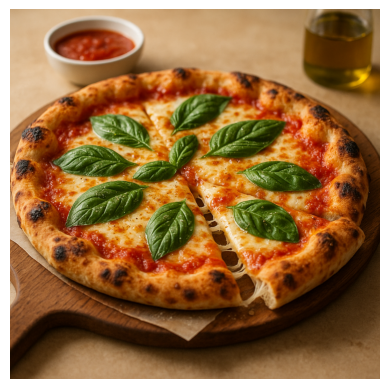

In [11]:
### Your Code Here
### Step 1.1: Load the json file. Define the loaded data as recipe_data.
 
with open('Recipes.json', 'r', encoding='utf-8') as f:
    recipe_data = json.load(f)

### Step 1.2: Print each key-value pair of the first recipe.
### In this format: key (type of value): value
recipe1 = recipe_data[0]
for key, value in recipe1.items():
    print(f"{key} ({type(value).__name__}): {value}")

### Step 1.3: Show the image of the first recipe (recipe1)

img = Image.open(f'synthetic_recipe_images/recipe{recipe1["id"]}.png')

plt.imshow(img)
plt.axis('off')
plt.show()
 
 

### Step 2: Define the vision LLM with LLaMA

### 第 2 步：使用 LLaMA 定义视觉 LLM

To generate meaningful textual descriptions from food images, you will use a vision-capable large language model (LLM). In this step, you will define and configure a **LLaMA-based vision model** that can process both images and text prompts.

为了从食物图像中生成有意义的文本描述，你将使用具有视觉能力的大语言模型（LLM）。在这一步中，你将定义并配置一个能够同时处理图像和文本提示的 **基于 LLaMA 的视觉模型**。

You will initialize the model with the appropriate credentials and inference parameters, and verify that it accepts image inputs and produces descriptive captions. This model will serve as the core component for converting visual information into natural language that can be integrated with your existing JSON-based knowledge structure.

你将使用适当的凭证和推理参数初始化模型，并验证它能够接受图像输入并生成描述性标题。这个模型将作为将视觉信息转化为自然语言的核心组件，并可与你现有的基于 JSON 的知识结构集成。

By completing this step, you will have a vision-enabled LLM ready to perform image captioning reliably and repeatably.

完成这一步后，你将拥有一个支持视觉能力的 LLM，能够稳定且可重复地执行图像字幕生成。


In [16]:
### Your Code Here: Fill in the blanks
import base64

def vision_llm(system_msg, prompt_txt, image_path):
    #system_msg: input system message for the LLM
    #prompt_txt: input user prompt for the LLM
    #image_path: the file path of the input image

    ### Credentials of the model
    model_id = 'meta-llama/llama-4-maverick-17b-128e-instruct-fp8'
    project_id="skills-network"
    credentials = Credentials(
                    url = "https://us-south.ml.cloud.ibm.com",
                    )
    generate_params = {"max_tokens": 300}

      ### Step 2.1: Define the model by ModelInference
    model = ModelInference(
        model_id=model_id,
        credentials=credentials,
        project_id=project_id,
        params=generate_params,
    )

    ### Step 2.2: Encode the input image to a base64 string
    with open(image_path, 'rb') as image_file:
        image_b64 = base64.b64encode(image_file.read()).decode('utf-8')

    ### Step 2.3: Define the messages for the model
    messages = [
        {'role': 'system', 'content': system_msg},
        {
            'role': 'user',
            'content': [
                {'type': 'text', 'text': prompt_txt},
                {
                    'type': 'image_url',
                    'image_url': {
                        'url': f'data:image/jpeg;base64,{image_b64}'
                    }
                }
            ]
        }
    ]

    ### Step 2.4: Get the response for the messages 
    response = model.chat(messages=messages)

    return response['choices'][0]['message']['content']

### Step 3: Design and validate prompts for the vision LLM

### 第 3 步：为视觉 LLM 设计并验证提示词

To ensure the vision LLM generates useful and consistent image captions, careful prompt design is essential. In this step, you will create a prompt that instructs the model to focus on relevant visual details, such as ingredients, cooking style, and presentation, while avoiding unnecessary or speculative information.

为了确保视觉 LLM 生成有用且一致的图像标题，精心设计提示词至关重要。在这一步中，你将创建一个提示词，指导模型关注与食材、烹饪风格和呈现方式相关的视觉细节，同时避免不必要或推测性的内容。

Once the prompt is defined, you will perform a simple unit test by running the model on a small sample of food images. This allows you to verify that the generated captions are accurate, concise, and suitable for integration into the existing JSON data structure.

一旦提示词定义完成，你将通过在一小组食物图像上运行模型来执行一个简单的单元测试。这能帮助你验证生成的标题是否准确、简洁，并适合集成到现有的 JSON 数据结构中。

By the end of this step, you will have a validated prompt that reliably converts food images into high-quality textual descriptions.

到这一步结束时，你将拥有一个已经验证过的提示词，能够稳定地将食物图像转换为高质量的文本描述。


In [17]:
### Your Code Here

### Define the food image caption prompts given a food name.
### The food name, as you have noticed, comes from the corresponding recipe data.
### You want to include the food name to ensure the model focuses on it while giving captions.
def image_caption_prompt_template(food_name):
    # food_name: the food name of the recipe
    image_caption_system_msg = "You are a professional food critic and culinary analyst."
    image_caption_prompt_txt = f"""
    Look at this image of {food_name}.
    Provide a concise description of its visual presentation, including the colors,
    textures, and how the dish is arranged on the plate.
    """
    return image_caption_system_msg, image_caption_prompt_txt


### Test the prompts on the first recipe
### Step 3.2: Get the prompts with the food name of the first recipe

food_name = recipe_data[0]['name']
system_msg, prompt_txt = image_caption_prompt_template(food_name)
test_img_path = f"synthetic_recipe_images/recipe{recipe_data[0]['id']}.png"

### Step 3.3: Get the test response and print it
response = vision_llm(system_msg, prompt_txt, test_img_path)
print(response)

The image presents a Classic Margherita Pizza, showcasing a harmonious blend of colors, textures, and arrangement on the plate. 
#### Visual Presentation:
* **Colors:** The pizza features a golden-brown crust with dark spots from charring, a vibrant red sauce, melted white cheese, and fresh green basil leaves.
* **Textures:** The crust appears crispy with a slightly charred texture, while the cheese is melted and smooth. The basil leaves add a fresh, herbaceous element.
* **Arrangement:** The pizza is cut into six slices, with one slice partially pulled away from the rest. It is placed on a round wooden board, accompanied by a small bowl of red sauce and a glass bottle of olive oil in the background. The pizza is centered on the board, with the basil leaves arranged in a symmetrical pattern on top.

The overall presentation is appetizing and inviting, with a focus on showcasing the simplicity and elegance of the Classic Margherita Pizza.


### Step 4: Caption all images and augment the data

### 第 4 步：为所有图像生成标题并增强数据

With a validated prompt and a working vision LLM, you will now scale the image captioning process across the entire dataset. In this step, you will iterate through all food images, generate captions for each one, and associate the results with their corresponding recipe or restaurant records.

在拥有已验证的提示词和可工作的视觉 LLM 后，你现在可以把图像标题生成流程扩展到整个数据集。在这一步中，你将遍历所有食物图像，为每张图像生成标题，并将结果与对应的食谱或餐厅记录关联起来。

You will then augment the existing JSON data by adding the generated image captions as new fields, ensuring the final structure remains consistent and machine-readable. This enriched dataset combines textual and visual insights into a unified representation, extending the structured knowledge base created in the previous lessons.

随后，你将通过将生成的图像标题作为新字段添加到现有 JSON 数据中来增强数据，确保最终结构保持一致且可被机器读取。这个增强后的数据集将文本和视觉见解组合成一个统一的表示，扩展了前几课中创建的结构化知识库。

By the end of this step, you will have a multimodal JSON file that integrates image-derived descriptions with existing structured data, ready for downstream GenAI applications.

到这一步结束时，你将拥有一个多模态 JSON 文件，它将图像衍生的描述与现有结构化数据整合在一起，准备用于下游生成式人工智能应用。


In [ ]:
### Your Code Here:

### Get captions for each image in the dataset and add to the JSON file (up tp 15 minutes)
### recipe_data is the recipe you loaded in Step 1
for i in range(len(recipe_data)):
    if (i+1)%20 == 0:
        print(f'{i+1} out of {len(recipe_data)} is done')

   ### Step 4.1: Get the caption prompts
    food_name = recipe_data[i]['name']
    recipe_id = recipe_data[i]['id']
    system_msg, prompt_txt = image_caption_prompt_template(food_name)
    img_path = f"synthetic_recipe_images/recipe{recipe_id}.png"

    ### Step 4.2: Get the response with the prompts
    response = vision_llm(system_msg, prompt_txt, img_path)

    ### Save the response as another item in the recipe data
    recipe_data[i]['image_description'] = response
print('ALL DONE!')



Take a screenshot of the Python code, clearly showing your implementation and the output from Step 2. Name the screenshot `M1L2_caption_all_recipes.jpg`.

请截取 Python 代码的屏幕截图，清楚显示你的实现和步骤 2 的输出。将截图命名为 `M1L2_caption_all_recipes.jpg`。


### Step 5: Save the image-caption-augmented recipe data

### 第 5 步：保存已添加图像标题的食谱数据

Save your data by running the following code.

运行以下代码来保存你的数据。


In [ ]:
filename = 'augmented_food_recipe.json'
with open(filename, 'w', encoding='utf-8') as f:
    json.dump(recipe_data, f, indent=4)

You can download the saved JSON file to your local folder. Be sure to store it in a safe location, as you will need it for future assignments.

你可以将保存好的 JSON 文件下载到本地文件夹中。请务必将其存放在安全的位置，因为你后续作业还会用到它。


----


## **Exercise 2: Preprocess the user visit history**

## **练习 2：预处理用户访问历史**

In this exercise, you will largely replicate the workflow from **Exercise 1**. The core steps, data exploration, prompt design, model inference, and JSON augmentation, remain the same.

在这个练习中，你将很大程度上复用 **练习 1** 的工作流。核心步骤——数据探索、提示词设计、模型推理和 JSON 增强——都保持不变。

The key difference lies in **prompt design**. Instead of focusing on food images, you will tailor your prompt to generate concise, informative descriptions from user visit history data, such as contextual cues from URLs or associated images combined with their written reviews. These prompts should emphasize elements that help explain user preferences and behavior while maintaining consistency with the existing JSON schema.

关键区别在于 **提示词设计**。你不再聚焦食物图像，而是根据用户访问历史数据来定制提示词，例如结合 URL 或关联图像以及书面评价中的上下文线索，生成简洁且有信息量的描述。这些提示词应强调有助于解释用户偏好和行为的元素，同时保持与现有 JSON 模式的一致性。

By the end of this exercise, you will have enriched the user visit history data with structured, machine-readable descriptions, further expanding the multimodal knowledge base built throughout this lab.

到这个练习结束时，你将为用户访问历史数据添加结构化、可机器读取的描述，进一步扩展整个实验中构建的多模态知识库。


### Step 1: Load the user review data

### 第 1 步：加载用户评价数据

Similar to Step 1 of Exercise 1, complete the following code block to load and explore the user review data.

与练习 1 的第 1 步类似，请完成下面的代码块来加载并探索用户评价数据。


In [22]:
### Part 1
### Your Code Here
### Step 1.1: Load the review dataset with variable name user_review_data
with open('Synthetic-User-Reviews.json', 'r', encoding='utf-8') as f:
    user_review_data = json.load(f)

### Step 1.2: Print the first review by key-value pairs
for key, value in user_review_data[0].items():
    print(f"{key} ({type(value).__name__}): {value}")



reviewId (int): 900000001
userId (str): USER_FUSION_FINDER_99
itemId (int): 1000001
title (str): A bit pricey, but that greenhouse vibe is so cozy
text (str): The Gilded Artichoke is definitely an upscale splurge. The lavender-rubbed chicken is unique, almost giving me tea-smoked vibes. It's a gorgeous, plant-filled escape from the city, though your wallet will feel it.
date (str): 2025-11-15
rating (float): 4.5
language (str): en
images (str): ['https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/L0HyLOGuAlxwKZaCC8sJdg/Gemini-Generated-Image-523rkg523rkg523r.png','https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YLCD9AYY985XxvP-K8CRbA/Gemini-Generated-Image-hy4y8why4y8why4y.png']


Let's look at the 'images' item. Although it looks like a list, it is actually a list in string type. Therefore, you need to be careful and convert the string to the actual Python list. Complete the code block below to display the first review image of the first restaurant visit.

让我们看一下 `images` 项目。虽然它看起来像一个列表，但实际上它是字符串类型的列表。因此，你需要小心地将字符串转换为实际的 Python 列表。请完成下面的代码块，以显示第一次餐厅访问的第一张评价图片。


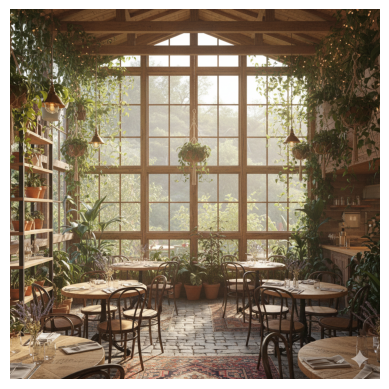

In [24]:
### Part 2
### Your Code Here
### Get the image by requesting from the URL
import ast # needed to convert string representation of list to actual python list
import requests
### Convert the list of images of the first user into the actual python list
### Step 1.3: Use ast.literal_eval to convert
review_images_list = ast.literal_eval(user_review_data[0]['images'])
### Step 1.4: Use the requests.get() method to get the image content
image_response = requests.get(review_images_list[0])
### Step 1.5: Write the image content in Step 1.4 to a temporary file 'review_image_placeholder.jpg'
### 将步骤1.4中的图像内容写入临时文件‘review_image_placeholder.jpg’
with open('review_image_placeholder.jpg', 'wb') as img_file:
    img_file.write(image_response.content)
### Step 1.6: Open the 'review_image_placeholder.jpg', and show th image
img = Image.open('review_image_placeholder.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()

### Step 2: Define the prompt and the validation

### 第 2 步：定义提示词并进行验证

Again, you will design a prompt template for the vision task and perform a unit test to validate the model’s behavior. However, unlike the previous exercise, this prompt must **incorporate textual context from user reviews** to guide the image captioning process.

同样，你将为视觉任务设计一个提示词模板，并执行一个单元测试来验证模型的行为。不过，与前一个练习不同的是，这个提示词必须 **结合用户评价中的文本上下文** 来引导图像标题生成过程。

In this step, you will define a prompt template function that takes user review text as input and uses it as contextual information when describing a food image. The system message assigns the model the role of a culinary expert, while the prompt instructs the model to generate a concise image description that aligns with the sentiment and details expressed in the reviews.

在这一步中，你将定义一个提示词模板函数，它接收用户评价文本作为输入，并在描述食物图像时将其用作上下文信息。系统消息会为模型指定烹饪专家的角色，而提示词会要求模型生成一个简洁的图像描述，使其与评价中表达的情感和细节保持一致。

After defining the prompt template, you will perform a unit test by running the vision LLM on a single image and its associated reviews. This test allows you to verify that the generated caption effectively combines visual information from the image with contextual cues from the reviews before applying the prompt at scale in later steps.

定义好提示词模板后，你将对单张图像及其相关评价运行视觉 LLM，执行一次单元测试。这个测试可以帮助你验证生成的标题是否有效地将图像中的视觉信息与评价中的上下文线索结合起来，然后再在后续步骤中大规模应用该提示词。


In [25]:
### Your Code Here:
### Prompt template: caption the images with the context of the reviews
def review_context_image_caption_prompt_template(reviews):
    # reviews: the written review content
 ### Step 2.1: Design your prompts
    review_context_image_caption_system_msg = """
    You are a culinary expert who helps analyze user-uploaded food photos.
    Your goal is to describe the image while considering the user's written feedback.
    """
    review_context_image_caption_prompt_txt = f"""
    The user wrote the following review: "{reviews}"
    Please describe the associated image. Focus on whether the visual details
    match the description in the review (e.g., specific dishes, presentation, or vibes).
    """

    return review_context_image_caption_system_msg, review_context_image_caption_prompt_txt 

### Step 2.2: Get the prompts
system_msg, prompt_txt = review_context_image_caption_prompt_template(user_review_data[0]['text'])

### Step 2.3: Get the response by the vision_llm you defined previously
response = vision_llm(system_msg, prompt_txt, 'review_image_placeholder.jpg')
print(response)

The image depicts a serene and inviting restaurant setting, with a spacious dining area surrounded by lush greenery. The room is filled with numerous plants, both on shelves and hanging from the ceiling, creating a natural ambiance. The tables are set with fine china, glassware, and silverware, suggesting an upscale dining experience.

**Key Features:**

* **Ambiance:** The atmosphere is tranquil, with soft lighting and an abundance of plants.
* **Dining Area:** The dining area features several round wooden tables, each set with elegant table settings.
* **Decor:** The walls are adorned with large windows, allowing natural light to pour in and illuminate the space. The ceiling is made of wood, adding warmth to the atmosphere.
* **Plants:** The presence of many plants contributes to the "plant-filled escape" described in the review.

**Comparison to Review:**

* The image aligns with the review's description of "The Gilded Artichoke" as a "gorgeous, plant-filled escape from the city."
*

### Step 3: Caption all images and augment the data

### 第 3 步：为所有图像生成标题并增强数据

Now, you are ready to get all captions with a for loop! Complete and run the following code block to caption all the review images.

现在，你已经准备好使用 for 循环生成所有标题了！请完成并运行下面的代码块，为所有评价图像生成标题。


In [ ]:
### Your Code Here

from tenacity import retry, stop_after_attempt, wait_exponential

### URL Request function with Retry
# Retries up to 10 times, starting at 1s and doubling (1s, 2s, 4s...)
@retry(stop=stop_after_attempt(10), wait=wait_exponential(multiplier=1, min=1, max=10))
def get_data_with_retry(url):
    response = requests.get(url, timeout=5)
    response.raise_for_status() # Must raise error for retry to trigger
    return response

### Start the for loop
for i in range(len(user_review_data)):
    ### Step 3.1: Convert the string to the Python list of image urls
    review_images = ast.literal_eval(user_review_data[i]['images'])
    
    review_text = user_review_data[i]['text']
    review_image_captions = []
    if len(review_images) > 0:
        for img_url in review_images:
            try:
                ### Step 3.2: Use get_data_with_retry to get the image_data
                image_data =  get_data_with_retry(img_url)
                print("Success!")
            except Exception as e:
                print(f"All retries failed at url {img_url}:", e)
                continue
            image = image_data.content
            with open('review_image_placeholder.jpg', 'wb') as img_file:
                img_file.write(image)

            ### Step 3.3: Get the prompts, get the response, 
            ### and finally append the response to review_image_captions
            system_msg, prompt_txt = review_context_image_caption_prompt_template(review_text)
            response = vision_llm(system_msg, prompt_txt, 'review_image_placeholder.jpg')
            review_image_captions.append(response)
    ### Append the review_image_captions to the review data
    user_review_data[i]['image_captions'] = review_image_captions
print('ALL DONE!')

Success!
Success!
Success!
Success!
Success!
Success!
Success!


### Step 4: Save the image-caption-augmented user review data

### 第 4 步：保存已添加图像标题的用户评价数据


Run the following code block to save the augmented review data:

运行下面的代码块来保存增强后的评价数据：


In [ ]:
filename = 'augmented_user_review.json'
with open(filename, 'w', encoding='utf-8') as f:
    json.dump(user_review_data, f, indent=4)

You can download the saved JSON file to your local folder. Be sure to store it in a safe location, as you will need it for future assignments.

你可以将保存好的 JSON 文件下载到本地文件夹中。请务必将其存放在安全的位置，因为你后续作业还会用到它。


----


## **Conclusion**

## **结论**

You have successfully applied GenAI tools to transform the unstructured text data into a well-structured JSON file!

你已经成功应用生成式人工智能工具，将非结构化文本数据转化为结构良好的 JSON 文件！


## Authors

## 作者


[Jianping (Mike) Ye](https://www.linkedin.com/in/jianping-ye/)

[ Jianping (Mike) Ye ](https://www.linkedin.com/in/jianping-ye/)


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2026-02-03|1|Jianping Ye|Create lab|
|2026-02-10|2|Jojy John|ID Reviewed|-->

<!--## 更改日志
|日期 (YYYY-MM-DD)|版本|修改者|变更说明|
|-|-|-|-|
|2026-02-03|1|Jianping Ye|创建实验|
|2026-02-10|2|Jojy John|已进行 ID 审核|-->


©IBM Corporation. All rights reserved.

©IBM Corporation. 保留所有权利。
